----
----
#  EXPLANATION NOTEBOOK:   

In this notebook we will Detail the workflow of our algorithm (main.py)
----
----
----

## IMPORT


In [1]:
from src.model_initialization import load_yolo_model, load_posenet_model, load_depth_estimation_model
from src.calibration import process_and_plot_calibration
from src.depth_estimation import estimate_depth
from src.direction_speed import calculate_direction, calculate_speed
from src.cost_map import create_dynamic_obstacles, create_time_dependent_cost_map, animate_cost_map
from src.draw_boxes import detect_persons
from src.navigation_algo import probabilistic_astar, display_path
from src.utils import preprocess_boxes, calculate_pixel_value, horizontal_pixel_pos, horizontal_pos_conversion, predict_distance, get_image_size, resize_to_x_by_x, create_hardcoded_obstacle

----
----
## Models initialisation: 


In [2]:
yolo_model = load_yolo_model()
posenet_model = load_posenet_model()
depth_processor, depth_model = load_depth_estimation_model()

Using cache found in /Users/paulrichard/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-8-13 Python-3.8.18 torch-2.0.1 CPU

Fusing layers... 
YOLOv5n summary: 213 layers, 1867405 parameters, 0 gradients
Adding AutoShape... 


YOLOv5 model loaded successfully.
MoveNet (PoseNet) model loaded successfully.
Depth estimation model loaded successfully.



----
----
## Calibration:

Here is the method we used to find best fitting curve

In [3]:
%matplotlib inline

input_folder = '/Users/prichard/miniconda3/envs/infosys/cv_project/data/input/calibration/normal_size'
output_folder = '/Users/prichard/miniconda3/envs/infosys/cv_project/data/output'
#best_model, prediction_param = process_and_plot_calibration(input_folder, yolo_model, depth_processor, depth_model, output_folder)
best_model = "Polynomial"
prediction_param = (0.00029224, -0.10041, 8.3828)

Small image error = 0.2629 \
Medium image error = 0.2126 \
High image error = 0.2082 \
Normal image error = 0.1980


![Curve Data](images/Curve_Data_Big1_512.png)
![Curve Data](images/Curve_Data_Big1_1024.png)
![Curve Data](images/Curve_Data_Big1_2048.png)
![Curve Data](images/Curve_Data_Big1_3000.png)


Person detection complete. Found 2 persons.
Direction estimation complete


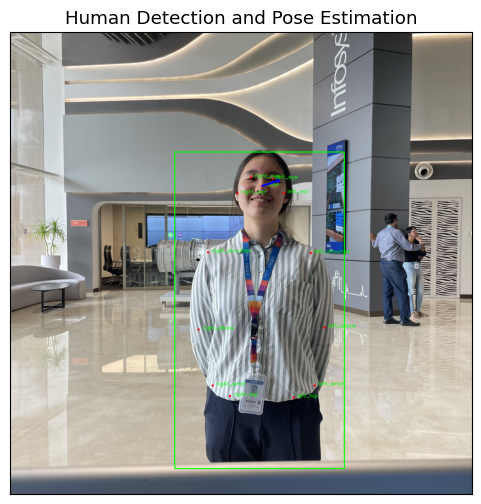

In [4]:
test_image_path = "data/input/calibration/high_size/0.9.jpeg"
DISP = True

robot_speed = 1.11 #  [m/s]

new_size = (1280, 1280)

img, size_img = get_image_size(test_image_path)

resized_image = resize_to_x_by_x(img, new_size)

depth_image = estimate_depth(resized_image, depth_processor, depth_model) # 0.5
coords_box_in_pixel = detect_persons(resized_image, yolo_model) # traduire dans la nouvelle map et pour l'instant mettre tout en cm avec juste pixel = 0.1 cm

filtered_depth_images = preprocess_boxes(depth_image, coords_box_in_pixel)
pixel_values = calculate_pixel_value(filtered_depth_images)

horizontal_pos_in_pixel = horizontal_pixel_pos(coords_box_in_pixel)
horizontal_pos_in_cm = horizontal_pos_conversion(horizontal_pos_in_pixel) # here we change the coordinates st the 0,0 is the robot position 

depth_values = [predict_distance(pv, prediction_param, best_model.lower()) for pv in pixel_values]

directions = calculate_direction(resized_image, coords_box_in_pixel, depth_values, posenet_model, DISP)
speeds = calculate_speed(resized_image, coords_box_in_pixel)


In [5]:
dynamic_obstacles = create_dynamic_obstacles(depth_values, horizontal_pos_in_cm, directions, speeds, time_steps=100, dt=10)


In [15]:
import numpy as np

# Function to create obstacles already inside the grid
def create_internal_obstacles(num_obstacles, grid_size, time_steps=100, dt=10):
    dynamic_obstacles = []
    
    for _ in range(num_obstacles):
        initial_x = np.random.uniform(-640, 640)  # Random x position within the grid
        initial_y = np.random.uniform(0, 1000)  # Random y position within the grid
        direction = np.random.uniform(0, 2 * np.pi)  # Random direction
        speed = np.random.uniform(10, 50)  # Random speed in cm/s
        
        initial_coordinates = np.array([int(initial_x), int(initial_y)])
        future_coordinates = np.zeros((time_steps, 2), dtype=int)
        
        for t in range(time_steps):
            futur_x = int(initial_coordinates[0] + np.cos(direction) * speed * t * dt)
            futur_y = int(initial_coordinates[1] + np.sin(direction) * speed * t * dt)
            future_coordinates[t] = [futur_x, futur_y]
        
        dynamic_obstacles.append((future_coordinates, direction, speed))
    
    return dynamic_obstacles

# Function to create obstacles entering from the edges
def create_entry_obstacles(num_obstacles, grid_size, entry_speed, time_steps=100, dt=10):
    dynamic_obstacles = []
    
    for _ in range(num_obstacles):
        # Randomly choose an entry side: 0=left, 1=right, 2=top, 3=bottom
        side = np.random.choice([0, 1, 2, 3])
        if side == 0:  # Left edge
            initial_x = -650  # Just outside the grid
            initial_y = np.random.uniform(0, grid_size[1])  # Random y position
            direction = np.random.uniform(-np.pi / 4, np.pi / 4)  # Moving right
        elif side == 1:  # Right edge
            initial_x = 650  # Just outside the grid
            initial_y = np.random.uniform(0, grid_size[1])  # Random y position
            direction = np.random.uniform(3 * np.pi / 4, 5 * np.pi / 4)  # Moving left
        elif side == 2:  # Top edge
            initial_x = np.random.uniform(-640, 640)  # Random x position
            initial_y = 1050  # Just outside the grid
            direction = np.random.uniform(-3 * np.pi / 4, -np.pi / 4)  # Moving down
        else:  # Bottom edge
            initial_x = np.random.uniform(-640, 640)  # Random x position
            initial_y = -50  # Just outside the grid
            direction = np.random.uniform(np.pi / 4, 3 * np.pi / 4)  # Moving up
        
        speed = entry_speed
        initial_coordinates = np.array([int(initial_x), int(initial_y)])
        future_coordinates = np.zeros((time_steps, 2), dtype=int)
        
        for t in range(time_steps):
            futur_x = int(initial_coordinates[0] + np.cos(direction) * speed * t * dt)
            futur_y = int(initial_coordinates[1] + np.sin(direction) * speed * t * dt)
            future_coordinates[t] = [futur_x, futur_y]
        
        dynamic_obstacles.append((future_coordinates, direction, speed))
    
    return dynamic_obstacles


In [16]:

# Define parameters
num_internal_obstacles = 10
num_entry_obstacles = 10
grid_size = (1280, 1000)  # Grid dimensions (width, height)
entry_speed = 50  # Speed of obstacles entering the grid (cm/s)
time_steps = 100
dt = 10

# Create obstacles already inside the grid
internal_obstacles = create_internal_obstacles(num_internal_obstacles, grid_size, time_steps, dt)

# Create obstacles entering from the edges
entry_obstacles = create_entry_obstacles(num_entry_obstacles, grid_size, entry_speed, time_steps, dt)

# Combine both internal and entry obstacles
dynamic_obstacles = internal_obstacles + entry_obstacles

cost_map = create_time_dependent_cost_map(dynamic_obstacles, time_steps)


TypeError: create_time_dependent_cost_map() takes from 1 to 2 positional arguments but 3 were given

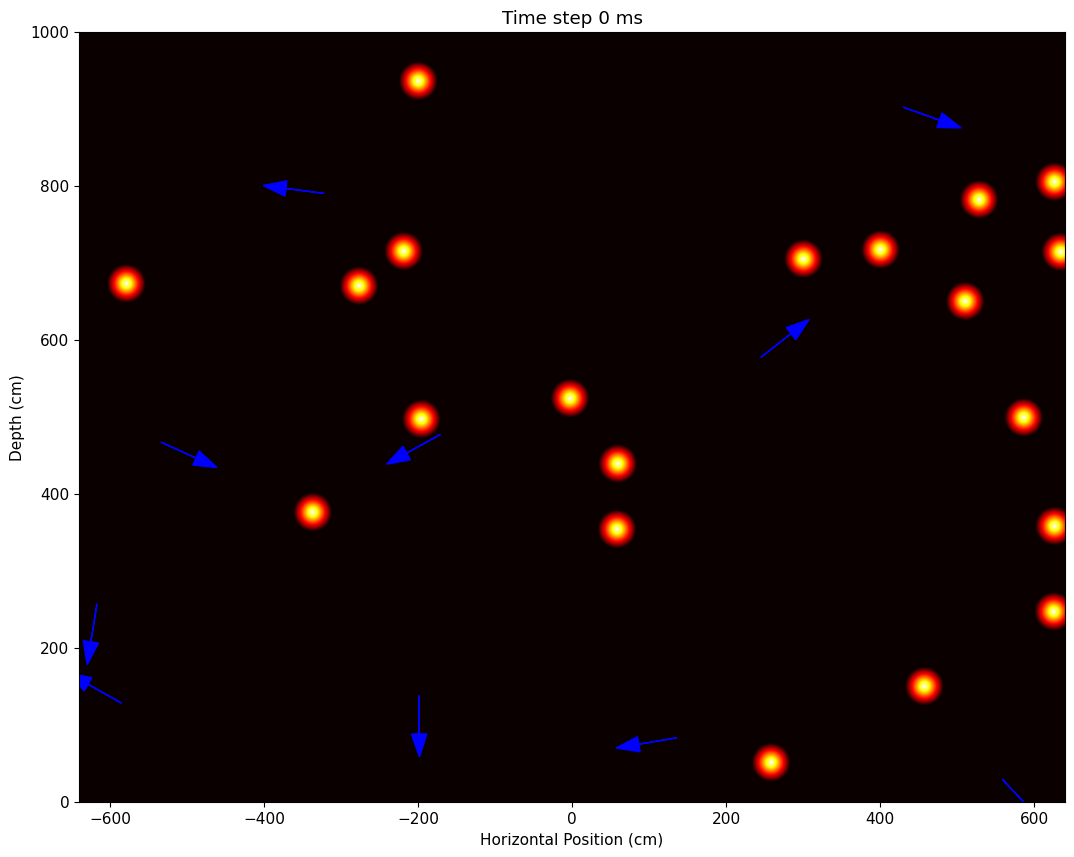

In [17]:
from IPython.display import HTML 
# To display the animation in a Jupyter notebook:
anim = animate_cost_map(cost_map, dynamic_obstacles, time_steps=100, dt=10, interval=100)
HTML(anim.to_jshtml())

A Faire Demain: Prendre les nouvelles image avec le truc à 1 m \
recomparer les erreurs\
faire une matrice pour representer la map \
mettre en proba et essayer de plot 
